# Model Training & Cross-Validation
**Author:** Anuj Saini  
**Date:** July 14, 2026

This notebook trains and evaluates multiple forecasting models using **time-series cross-validation** (expanding window) and a **recursive forecasting pipeline** to predict weekly demand over a 4-week horizon (weeks $t+1$ to $t+4$).

We compare:
1. **Naive Baseline:** Carries forward the last known week's actual demand.
2. **Linear Regression:** Baseline parametric regression model.
3. **Random Forest:** Non-parametric ensemble of decision trees.
4. **Gradient Boosting:** Non-parametric boosted trees ensemble.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Add src to python path
sys.path.append(os.path.abspath('..'))
from src.features import build_features

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Connection details
host = "aws-0-ap-south-1.pooler.supabase.com"
port = "5432"
database = "postgres"
username = "ecom_ro_user.imnzftquwjuxcwpeufwp"
password = "work-experience-read-only"

conn_url = f"postgresql://{username}:{password}@{host}:{port}/{database}"
engine = create_engine(conn_url)
print("Database connection initialized.")

Database connection initialized.


In [2]:
# Load transaction data
query = """
    SELECT o.created_at, oi.qty, oi.unit_price, c.category_name
    FROM ecom.orders o
    JOIN ecom.order_items oi ON o.order_id = oi.order_id
    JOIN ecom.product_variants pv ON oi.variant_id = pv.variant_id
    JOIN ecom.products p ON pv.product_id = p.product_id
    JOIN ecom.categories c ON p.category_id = c.category_id;
"""
df_raw = pd.read_sql(query, engine)
df_raw['created_at'] = pd.to_datetime(df_raw['created_at'])
df_raw['week_start'] = df_raw['created_at'].dt.to_period('W').dt.start_time

# Aggregate to weekly category level
weekly_actuals = df_raw.groupby(['week_start', 'category_name']).agg(
    qty=('qty', 'sum'),
    avg_price=('unit_price', 'mean')
).reset_index().sort_values(by=['category_name', 'week_start']).reset_index(drop=True)

unique_weeks = sorted(weekly_actuals['week_start'].unique())
print(f"Unique weeks: {len(unique_weeks)}")

Unique weeks: 13


/tmp/ipykernel_252052/3643109409.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_raw['week_start'] = df_raw['created_at'].dt.to_period('W').dt.start_time


In [3]:
# Generate features
df_features_all = build_features(df_raw)
print(f"Feature matrix size: {df_features_all.shape}")

Feature matrix size: (126, 15)


/home/anuj/Personal/DataBuoy-Projects-Testing/demand-forecasting-ml/src/features.py:23: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week_start'] = df['created_at'].dt.to_period('W').dt.start_time


In [4]:
# Define Cross-Validation Folds
# Fold 1: Train weeks 4-6, Validate weeks 7-10
# Fold 2: Train weeks 4-7, Validate weeks 8-11
# Fold 3: Train weeks 4-8, Validate weeks 9-12
folds = [
    {"train_weeks": list(range(4, 7)), "val_weeks": list(range(7, 11))},
    {"train_weeks": list(range(4, 8)), "val_weeks": list(range(8, 12))},
    {"train_weeks": list(range(4, 9)), "val_weeks": list(range(9, 13))}
]

def get_wmape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)

def run_recursive_forecast(model, train_df, val_weeks, weekly_all):
    feature_cols = [
        'qty_lag_1', 'qty_lag_2', 'qty_lag_3', 'qty_lag_4',
        'qty_roll_mean_2', 'qty_roll_std_2', 'qty_roll_mean_4', 'qty_roll_std_4',
        'price_lag_1', 'category_expanding_mean', 'time_idx'
    ]
    
    X_train = train_df[feature_cols]
    y_train = train_df['qty']
    model.fit(X_train, y_train)
    
    # We initialize history with the actuals up to the validation window start
    history = weekly_all[weekly_all['week_start'] < unique_weeks[val_weeks[0]]].copy()
    predictions = []
    
    # Loop over validation weeks recursively
    for val_week_idx in val_weeks:
        val_week = unique_weeks[val_week_idx]
        current_week_rows = weekly_all[weekly_all['week_start'] == val_week].copy()
        current_week_qty_actual = current_week_rows.set_index('category_name')['qty'].to_dict()
        
        # Mask current week's qty
        current_week_rows['qty'] = np.nan
        temp_df = pd.concat([history, current_week_rows], ignore_index=True)
        temp_df = temp_df.sort_values(by=['category_name', 'week_start']).reset_index(drop=True)
        
        # Recompute features programmatically
        grouped = temp_df.groupby('category_name')
        temp_df['qty_lag_1'] = grouped['qty'].shift(1)
        temp_df['qty_lag_2'] = grouped['qty'].shift(2)
        temp_df['qty_lag_3'] = grouped['qty'].shift(3)
        temp_df['qty_lag_4'] = grouped['qty'].shift(4)
        
        temp_df['qty_roll_mean_2'] = grouped['qty'].transform(lambda x: x.shift(1).rolling(2).mean())
        temp_df['qty_roll_std_2'] = grouped['qty'].transform(lambda x: x.shift(1).rolling(2).std())
        temp_df['qty_roll_mean_4'] = grouped['qty'].transform(lambda x: x.shift(1).rolling(4).mean())
        temp_df['qty_roll_std_4'] = grouped['qty'].transform(lambda x: x.shift(1).rolling(4).std())
        
        temp_df['price_lag_1'] = grouped['avg_price'].shift(1)
        temp_df['category_expanding_mean'] = grouped['qty'].transform(lambda x: x.shift(1).expanding().mean())
        
        min_week = temp_df['week_start'].min()
        temp_df['time_idx'] = ((temp_df['week_start'] - min_week).dt.days / 7).astype(int)
        
        # Predict for the week
        current_features = temp_df[temp_df['week_start'] == val_week].copy()
        X_val = current_features[feature_cols]
        preds = model.predict(X_val)
        
        current_features['qty_pred'] = preds
        current_features['qty_actual'] = current_features['category_name'].map(current_week_qty_actual)
        predictions.append(current_features[['week_start', 'category_name', 'qty_actual', 'qty_pred']])
        
        # Update history with predicted value
        current_week_rows['qty'] = current_week_rows['category_name'].map(dict(zip(current_features['category_name'], preds)))
        history = pd.concat([history, current_week_rows], ignore_index=True)
        
    return pd.concat(predictions, ignore_index=True)

In [5]:
# Evaluate Models in Cross-Validation
results_naive = []
results_lr = []
results_rf = []
results_gb = []

# We will store predictions for Fold 3 to plot them later
fold_3_preds = {}

for i, fold in enumerate(folds):
    train_weeks = fold['train_weeks']
    val_weeks = fold['val_weeks']
    
    max_train_week = unique_weeks[train_weeks[-1]]
    train_df = df_features_all[df_features_all['week_start'] <= max_train_week].copy()
    
    # 1. Naive Baseline
    last_train_week = unique_weeks[train_weeks[-1]]
    last_actuals = weekly_actuals[weekly_actuals['week_start'] == last_train_week].set_index('category_name')['qty'].to_dict()
    
    naive_preds = []
    for val_week_idx in val_weeks:
        val_week = unique_weeks[val_week_idx]
        current_actuals = weekly_actuals[weekly_actuals['week_start'] == val_week].copy()
        current_actuals['qty_pred'] = current_actuals['category_name'].map(last_actuals)
        naive_preds.append(current_actuals)
    df_naive_fold = pd.concat(naive_preds, ignore_index=True)
    wmape_naive = get_wmape(df_naive_fold['qty'], df_naive_fold['qty_pred'])
    results_naive.append(wmape_naive)
    
    # 2. Linear Regression
    lr_model = LinearRegression()
    df_lr_fold = run_recursive_forecast(lr_model, train_df, val_weeks, weekly_actuals)
    wmape_lr = get_wmape(df_lr_fold['qty_actual'], df_lr_fold['qty_pred'])
    results_lr.append(wmape_lr)
    
    # 3. Random Forest
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)
    df_rf_fold = run_recursive_forecast(rf_model, train_df, val_weeks, weekly_actuals)
    wmape_rf = get_wmape(df_rf_fold['qty_actual'], df_rf_fold['qty_pred'])
    results_rf.append(wmape_rf)
    
    # 4. Gradient Boosting
    gb_model = GradientBoostingRegressor(n_estimators=50, max_depth=3, learning_rate=0.1, random_state=42)
    df_gb_fold = run_recursive_forecast(gb_model, train_df, val_weeks, weekly_actuals)
    wmape_gb = get_wmape(df_gb_fold['qty_actual'], df_gb_fold['qty_pred'])
    results_gb.append(wmape_gb)
    
    if i == 2:  # Save Fold 3 predictions for visualization
        fold_3_preds['actual'] = df_gb_fold
        fold_3_preds['naive'] = df_naive_fold
        fold_3_preds['gb'] = df_gb_fold

print("=== CV Results per Fold ===")
for f_idx in range(len(folds)):
    print(f"Fold {f_idx+1}: Naive={results_naive[f_idx]:.4f}, LR={results_lr[f_idx]:.4f}, RF={results_rf[f_idx]:.4f}, GB={results_gb[f_idx]:.4f}")

=== CV Results per Fold ===
Fold 1: Naive=0.1280, LR=1.0620, RF=0.1553, GB=0.0890
Fold 2: Naive=0.1810, LR=0.6053, RF=0.1455, GB=0.1491
Fold 3: Naive=0.2642, LR=0.4455, RF=0.2468, GB=0.2461


In [6]:
# Print overall averages
print("=== Final CV Summary (Mean WMAPE +/- Std) ===")
print(f"Naive Baseline   : {np.mean(results_naive):.4f} +/- {np.std(results_naive):.4f}")
print(f"Linear Regression: {np.mean(results_lr):.4f} +/- {np.std(results_lr):.4f}")
print(f"Random Forest    : {np.mean(results_rf):.4f} +/- {np.std(results_rf):.4f}")
print(f"Gradient Boosting: {np.mean(results_gb):.4f} +/- {np.std(results_gb):.4f}")

lift = (np.mean(results_naive) - np.mean(results_gb)) / np.mean(results_naive) * 100
print(f"Relative Lift of Gradient Boosting over Baseline: {lift:.2f}%")

=== Final CV Summary (Mean WMAPE +/- Std) ===
Naive Baseline   : 0.1911 +/- 0.0560
Linear Regression: 0.7043 +/- 0.2612
Random Forest    : 0.1825 +/- 0.0456
Gradient Boosting: 0.1614 +/- 0.0647
Relative Lift of Gradient Boosting over Baseline: 15.53%


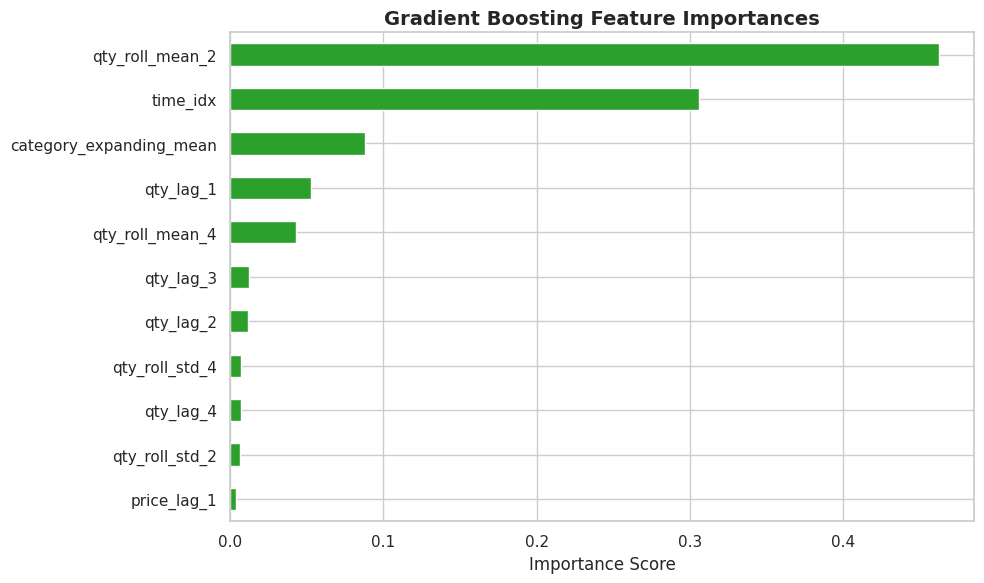

In [7]:
# Feature Importance Analysis (Gradient Boosting)
feature_cols = [
    'qty_lag_1', 'qty_lag_2', 'qty_lag_3', 'qty_lag_4',
    'qty_roll_mean_2', 'qty_roll_std_2', 'qty_roll_mean_4', 'qty_roll_std_4',
    'price_lag_1', 'category_expanding_mean', 'time_idx'
]
X_all = df_features_all[feature_cols]
y_all = df_features_all['qty']

gb_final = GradientBoostingRegressor(n_estimators=50, max_depth=3, learning_rate=0.1, random_state=42)
gb_final.fit(X_all, y_all)

importances = pd.Series(gb_final.feature_importances_, index=feature_cols).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#2ca02c')
plt.title('Gradient Boosting Feature Importances', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150)
plt.show()

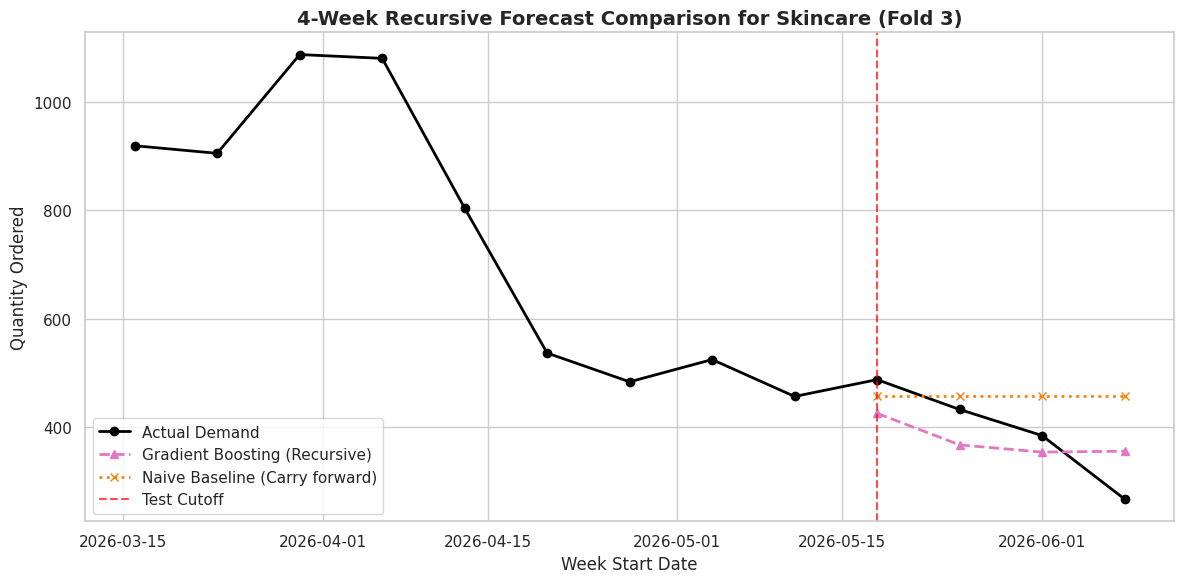

In [8]:
# Plot predictions vs actuals for Skincare in Fold 3
cat_name = 'Skincare'
actual_cat = weekly_actuals[weekly_actuals['category_name'] == cat_name].sort_values('week_start')

gb_pred_cat = fold_3_preds['gb'][fold_3_preds['gb']['category_name'] == cat_name].sort_values('week_start')
naive_pred_cat = fold_3_preds['naive'][fold_3_preds['naive']['category_name'] == cat_name].sort_values('week_start')

plt.figure(figsize=(12, 6))
plt.plot(actual_cat['week_start'], actual_cat['qty'], label='Actual Demand', color='black', marker='o', linewidth=2)
plt.plot(gb_pred_cat['week_start'], gb_pred_cat['qty_pred'], label='Gradient Boosting (Recursive)', color='#e377c2', marker='^', linestyle='--', linewidth=2)
plt.plot(naive_pred_cat['week_start'], naive_pred_cat['qty_pred'], label='Naive Baseline (Carry forward)', color='#ff7f0e', marker='x', linestyle=':', linewidth=2)

plt.axvline(x=pd.Timestamp('2026-05-18'), color='red', linestyle='--', alpha=0.7, label='Test Cutoff')
plt.title(f'4-Week Recursive Forecast Comparison for {cat_name} (Fold 3)', fontsize=14, fontweight='bold')
plt.xlabel('Week Start Date')
plt.ylabel('Quantity Ordered')
plt.legend()
plt.tight_layout()
plt.savefig('model_predictions_comparison.png', dpi=150)
plt.show()